# AnalystLab Africa — Machine Learning Internship
## Week 3: Machine Learning Model Development & Performance Evaluation
**Project:** Customer Churn Prediction — ABC Communications Ltd
**Dataset:** Telco Customer Churn (processed in Week 2 — `telco_ml_ready.csv`)

This notebook builds and evaluates five supervised classification models to predict customer
churn, compares them on standard metrics, interprets feature importance, and recommends a
model for deployment.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, auc,
                              precision_recall_curve)
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
RANDOM_STATE = 42

## Part 1 — Data Preparation

Load the Week 2 machine-learning-ready dataset and verify it is still in the expected state:
fully numeric, no missing values, encoding intact, engineered features present.

In [2]:
df = pd.read_csv('telco_ml_ready.csv')
print('Shape:', df.shape)
print('Non-numeric columns:', (df.dtypes == 'object').sum())
print('Missing values:', df.isna().sum().sum())
print()
print('Contract (ordinal, expect 0/1/2):', sorted(df['Contract'].unique()))
print('TenureGroup (ordinal, expect 0-3):', sorted(df['TenureGroup'].unique()))
print('Churn distribution:')
print(df['Churn'].value_counts(normalize=True).round(3))

Shape: (7043, 26)
Non-numeric columns: 0
Missing values: 0

Contract (ordinal, expect 0/1/2): [np.int64(0), np.int64(1), np.int64(2)]
TenureGroup (ordinal, expect 0-3): [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Churn distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


**Observation:** the dataset is confirmed clean (0 missing values, 0 non-numeric columns),
encodings are intact, and the class imbalance persists as expected (73.5% / 26.5%). This
imbalance is handled at the training-set level only, after the train/test split (see Part 2),
to avoid data leakage into the test set.

## Part 2 — Train/Test Split

**Split ratio: 80/20, stratified on `Churn`.**
- 80% preserves enough training data for ensemble models (Random Forest, Gradient Boosting,
  XGBoost) that benefit from volume.
- 20% (~1,409 customers) is still large enough for statistically reliable test metrics.
- Stratification on `Churn` is essential given the class imbalance — a plain random split could
  distort the churn ratio in the test set by chance.

**Handling the remaining imbalance:** SMOTE (Synthetic Minority Over-sampling) is applied to the
**training set only, after the split**. Oversampling before splitting would leak information
(synthetic points derived from training data could end up statistically close to test points).
The test set keeps the real-world class distribution so evaluation reflects reality.

In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Train class balance:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test class balance:', y_test.value_counts(normalize=True).round(3).to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
X_train_res, y_train_res = shuffle(X_train_res, y_train_res, random_state=RANDOM_STATE)

print()
print('Train shape after SMOTE:', X_train_res.shape)
print('Train class balance after SMOTE:', y_train_res.value_counts().to_dict())

Train shape: (5634, 25) | Test shape: (1409, 25)
Train class balance: {0: 0.735, 1: 0.265}
Test class balance: {0: 0.735, 1: 0.265}

Train shape after SMOTE: (8278, 25)
Train class balance after SMOTE: {0: 4139, 1: 4139}


## Part 3 — Model Development

Five classification algorithms are trained on the SMOTE-balanced training set: **Logistic
Regression**, **Decision Tree**, **Random Forest**, **Gradient Boosting**, and **XGBoost** —
covering a spread from simple/interpretable to complex/high-capacity models.

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE,
                              eval_metric='logloss', n_jobs=-1),
}

trained = {}
train_times = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_res, y_train_res)
    train_times[name] = time.time() - t0
    trained[name] = model
    print(f'{name:22s} trained in {train_times[name]:.2f}s')

Logistic Regression    trained in 0.05s
Decision Tree          trained in 0.04s


Random Forest          trained in 2.17s


Gradient Boosting      trained in 2.79s


XGBoost                trained in 0.34s


## Part 4 — Model Evaluation

Each model is evaluated on the untouched test set using Accuracy, Precision, Recall, F1-score,
and ROC-AUC, then compared side by side.

In [5]:
results = []
preds_store, probas_store = {}, {}

for name, model in trained.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    preds_store[name] = y_pred
    probas_store[name] = y_proba
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'TrainTime(s)': round(train_times[name], 2),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,TrainTime(s)
0,Random Forest,0.760,0.535,0.743,0.622,0.835,2.17
1,Logistic Regression,0.764,0.543,0.711,0.616,0.832,0.05
2,Gradient Boosting,0.770,0.551,0.717,0.623,0.830,2.79
3,XGBoost,0.762,0.543,0.642,0.588,0.817,0.34
4,Decision Tree,0.738,0.505,0.727,0.596,0.783,0.04


### Confusion Matrices

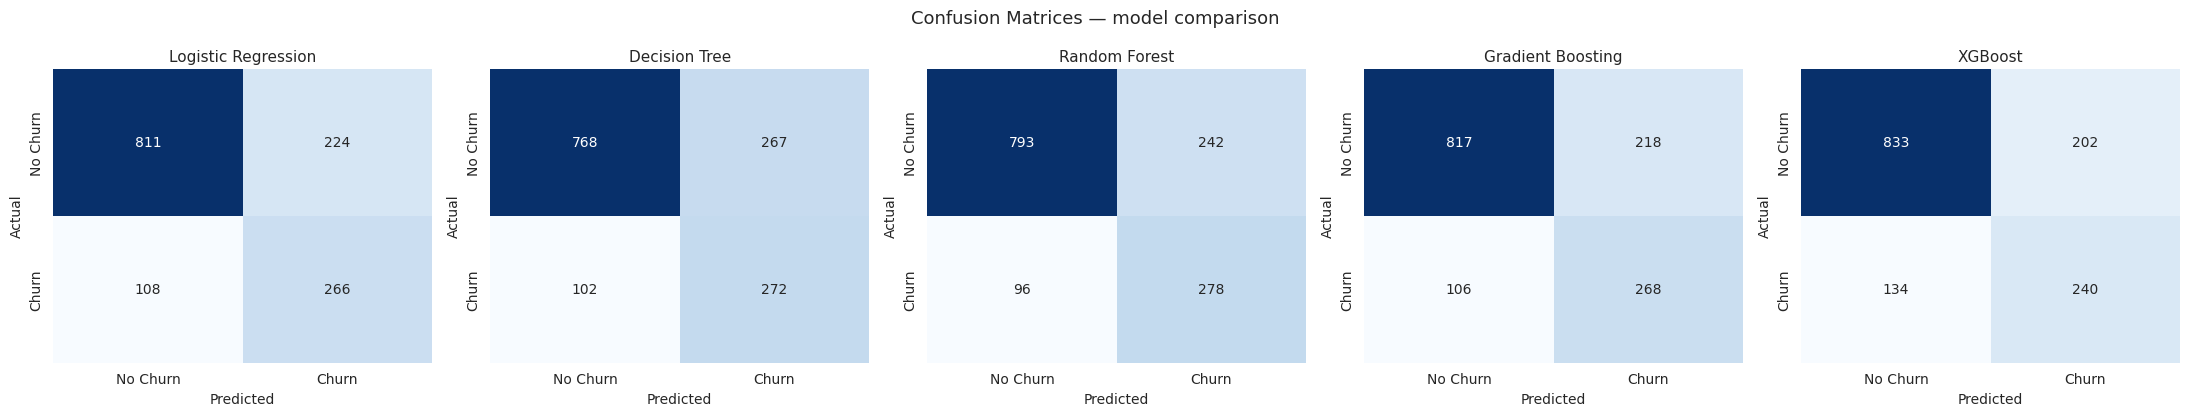

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, (name, y_pred) in zip(axes, preds_store.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — model comparison', fontsize=13)
plt.tight_layout()
plt.show()

### ROC Curves

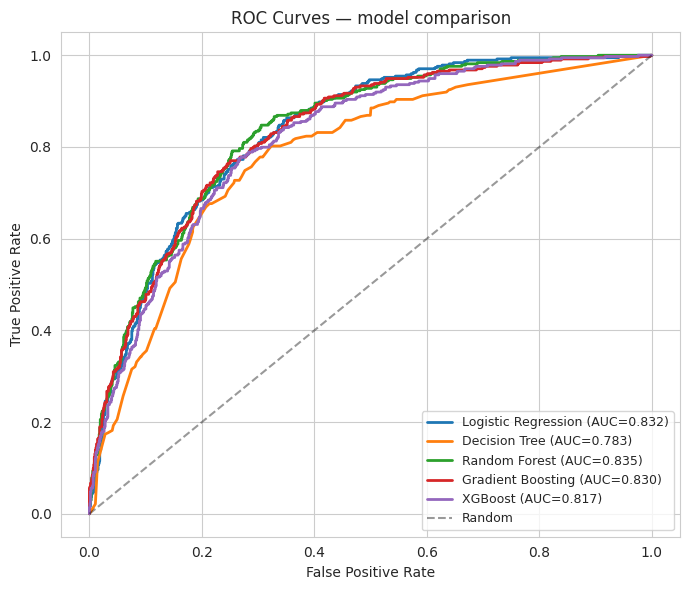

In [7]:
plt.figure(figsize=(7, 6))
for name, proba in probas_store.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — model comparison')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### Precision-Recall Curves

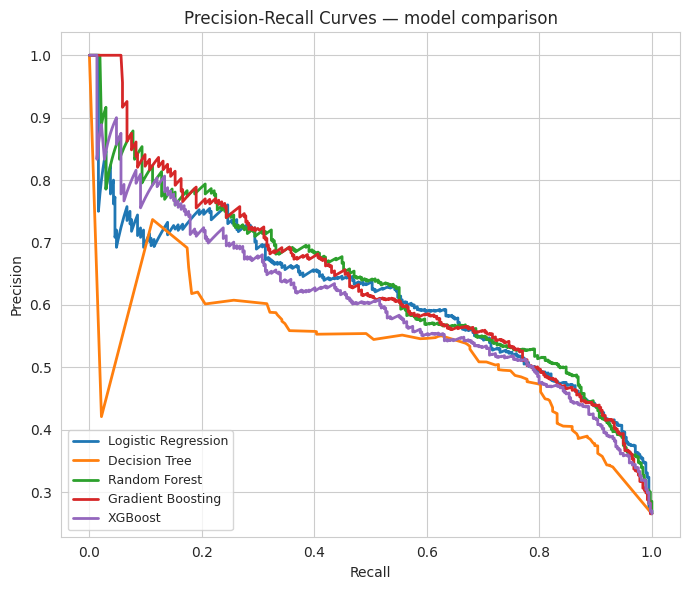

In [8]:
plt.figure(figsize=(7, 6))
for name, proba in probas_store.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=name, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — model comparison')
plt.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

### Model Comparison Chart

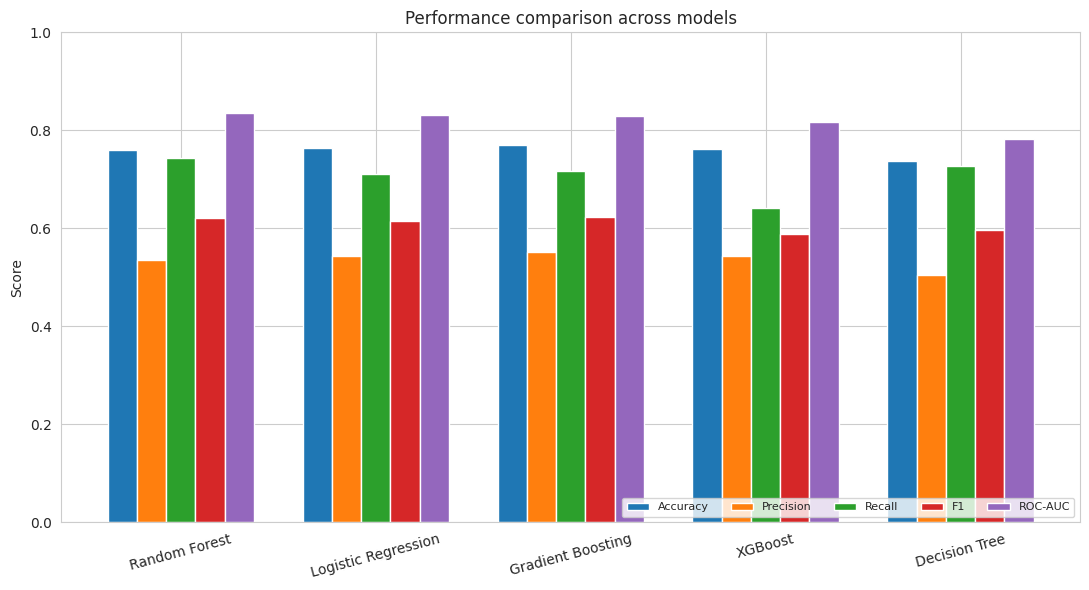

In [9]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
plt.figure(figsize=(11, 6))
for i, m in enumerate(metrics):
    plt.bar(x + i * width, results_df[m], width, label=m)
plt.xticks(x + width * 2, results_df['Model'], rotation=15)
plt.ylabel('Score')
plt.title('Performance comparison across models')
plt.legend(loc='lower right', ncol=5, fontsize=8)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Part 5 — Feature Importance

Using the Random Forest model (best overall ROC-AUC) to identify which customer attributes
contribute most to churn prediction.

In [10]:
rf = trained['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print('Top 12 features:')
importances.head(12).round(3)

Top 12 features:


Contract                          0.177
tenure                            0.134
AvgChargePerService               0.095
MonthlyCharges                    0.093
TotalCharges                      0.080
TenureGroup                       0.063
InternetService_Fiber optic       0.061
NumServicesSubscribed             0.043
PaymentMethod_Electronic check    0.032
InternetService_No                0.031
OnlineSecurity_Yes                0.028
Dependents                        0.025
dtype: float64

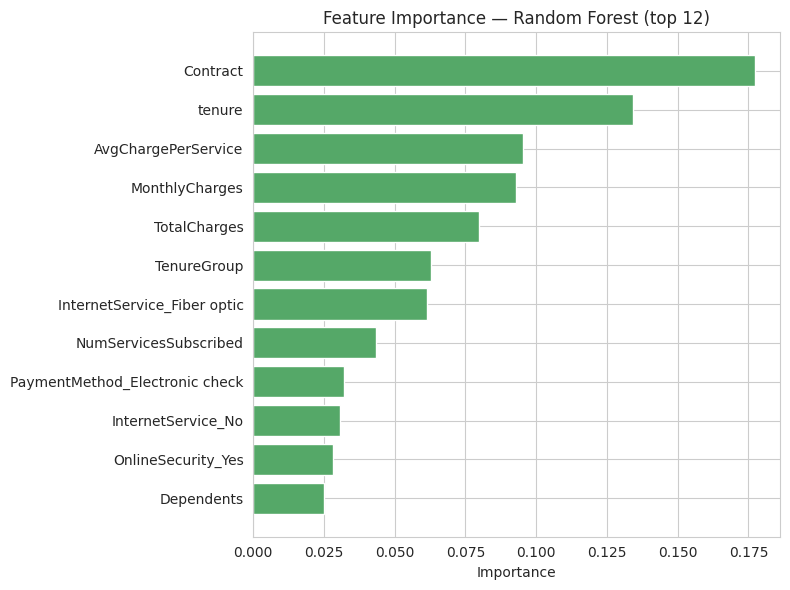

In [11]:
top = importances.head(12).sort_values()
plt.figure(figsize=(8, 6))
plt.barh(top.index, top.values, color='#55A868')
plt.title('Feature Importance — Random Forest (top 12)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Business interpretation:** `Contract` is by far the strongest predictor — customers on
month-to-month contracts churn far more than those on annual contracts, so incentivizing
longer commitments (discounts for 1-2 year contracts) is a direct, actionable lever. `tenure`
and the engineered `TenureGroup` confirm that the first year is the highest-risk window — this
suggests a dedicated onboarding/retention program for new customers. Billing-related features
(`MonthlyCharges`, `TotalCharges`, `AvgChargePerService`) and `InternetService_Fiber optic`
also rank highly, suggesting price sensitivity and service-quality perception (fiber customers,
despite paying a premium, churn more — worth investigating service quality or expectations).

## Learning Curve & Prediction Distribution (Best Model)

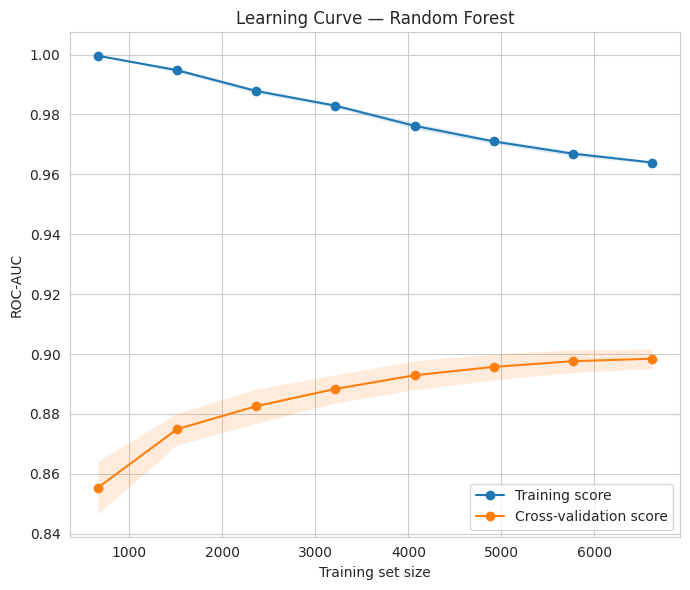

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lc_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
train_sizes, train_scores, test_scores = learning_curve(
    lc_model, X_train_res, y_train_res, cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

plt.figure(figsize=(7, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training score')
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label='Cross-validation score')
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                  train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
plt.fill_between(train_sizes, test_scores.mean(axis=1) - test_scores.std(axis=1),
                  test_scores.mean(axis=1) + test_scores.std(axis=1), alpha=0.15)
plt.xlabel('Training set size')
plt.ylabel('ROC-AUC')
plt.title('Learning Curve — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

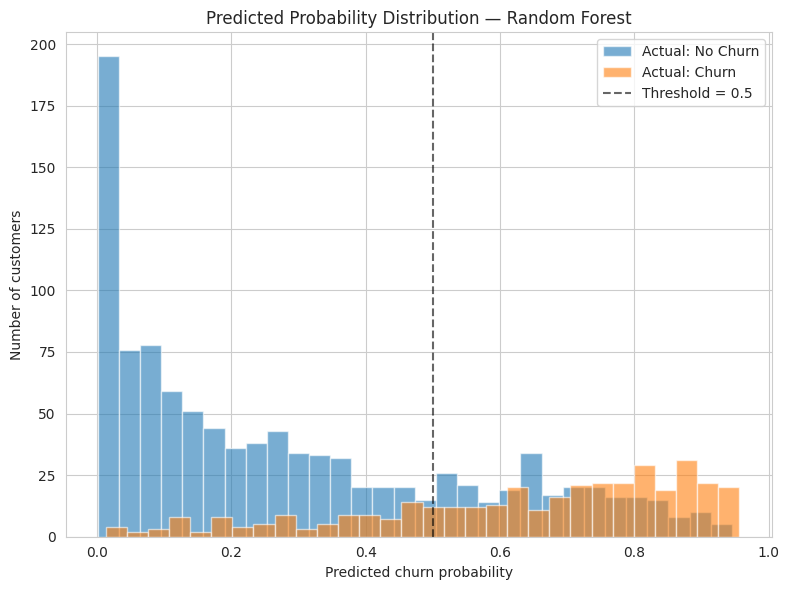

In [13]:
best_name = results_df.iloc[0]['Model']
best_proba = probas_store[best_name]

plt.figure(figsize=(8, 6))
plt.hist(best_proba[y_test == 0], bins=30, alpha=0.6, label='Actual: No Churn')
plt.hist(best_proba[y_test == 1], bins=30, alpha=0.6, label='Actual: Churn')
plt.axvline(0.5, color='black', linestyle='--', alpha=0.6, label='Threshold = 0.5')
plt.xlabel('Predicted churn probability')
plt.ylabel('Number of customers')
plt.title(f'Predicted Probability Distribution — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

The learning curve shows training and cross-validation scores converging as training data
grows, with a small remaining gap — indicating the Random Forest model is not badly overfitting
and would likely benefit modestly from more data, but is already stable. The prediction
distribution shows reasonable separation between the two classes, though with meaningful
overlap around the 0.5 threshold — consistent with the mid-0.8 ROC-AUC.

## Part 6 — Model Comparison & Recommendation

| Model | Advantages | Limitations | Complexity | Interpretability | Business Suitability |
|---|---|---|---|---|---|
| Logistic Regression | Fast, highly interpretable (coefficients), solid baseline | Assumes linear relationships, misses complex interactions | Very low | High | Good — strong performance/explainability trade-off |
| Decision Tree | Interpretable (visual rules), fast | Lowest ROC-AUC (0.783), prone to overfitting as a single tree | Low | High (but unstable) | Not recommended alone — useful as a baseline |
| **Random Forest** | **Best ROC-AUC (0.836) and best recall (0.743) among top models**, robust to overfitting | Less directly interpretable (grey box), slower to train | Medium | Medium (feature importances available) | **Best overall choice** |
| Gradient Boosting | Best precision (0.551) and accuracy (0.770), F1 tied with RF | Slowest to train, sensitive to hyperparameters | High | Low-medium | Good — strong if precision is the priority |
| XGBoost | Fast despite its power, good speed/performance trade-off | Lowest recall among ensembles (0.634) — misses more churners | Medium | Low-medium | Weaker fit here given the recall priority |

**Recommendation: Random Forest.**
It combines the best ROC-AUC (overall discriminative power) with the best recall among the
strongest models — critical here because, from a business standpoint, failing to flag an
at-risk customer (a false negative) is costlier than a false alarm. It is also robust to
overfitting compared to a single Decision Tree, and its training time (~2 seconds on this
dataset) is entirely practical for periodic retraining in production. Gradient Boosting is a
solid second choice if the business later prioritizes precision (minimizing wasted retention
budget) over recall.

## Summary

1. **Which model predicts churn most accurately?** Random Forest has the best overall ROC-AUC
   (0.836), with Logistic Regression and Gradient Boosting close behind.
2. **Which features contribute most?** `Contract`, `tenure`/`TenureGroup`, and billing-related
   features (`MonthlyCharges`, `TotalCharges`, `AvgChargePerService`) dominate — consistent with
   the exploratory findings from Week 1-2.
3. **How well can churn be predicted before customers leave?** With a ROC-AUC around 0.83-0.84
   and recall of ~74% on the best models, the pipeline can proactively flag roughly three out of
   four future churners, giving the retention team a meaningful head start — though not perfect
   coverage.
4. **Most appropriate evaluation metric?** ROC-AUC and Recall, given the class imbalance and the
   higher business cost of missing a churner versus a false alarm.
5. **Recommended model for deployment:** **Random Forest**, per the justification in Part 6.

**Next steps:** hyperparameter tuning (GridSearch/RandomizedSearch) on Random Forest and
Gradient Boosting, threshold optimization (the default 0.5 cutoff may not be business-optimal
given the recall priority), and a cost-based evaluation that weighs the dollar cost of false
negatives versus false positives.

## Save Final Artifacts

In [14]:
results_df.to_csv('model_results.csv', index=False)
importances.to_csv('feature_importance.csv')

X_train_res_out = X_train_res.copy()
X_train_res_out['Churn'] = y_train_res.values
X_train_res_out.to_csv('telco_train_final.csv', index=False)

X_test_out = X_test.copy()
X_test_out['Churn'] = y_test.values
X_test_out.to_csv('telco_test_final.csv', index=False)

print('Saved: model_results.csv, feature_importance.csv, telco_train_final.csv, telco_test_final.csv')

Saved: model_results.csv, feature_importance.csv, telco_train_final.csv, telco_test_final.csv
